# High Gods x subsistence x environment: an exploratory pass

**This notebook is exploratory, not inferential.** No p-values, no significance tests, no PERMANOVA. It looks for patterns worth naming and mediation paths worth tracing -- it does not test hypotheses. Null, mediated, and residual results are all fine outcomes and are reported as found.

EA034 (High Gods) is crossed against EA042 (dominant subsistence) and against basin-scale environmental signatures, in that order, because the working hypothesis under examination is specifically that any environment-religion association is **mediated through subsistence** (environment affords a subsistence mode; subsistence shapes social form) rather than direct. The tables either support that chain or they don't -- either way is reported plainly.

WO: `docs/edop/docsv4/wo1_exploratory-notebook.md`.

In [1]:
# Cell 1
%matplotlib inline
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.shared import db_utils
from scripts.shared.db_utils import db_connect
from scripts.cdop.distance_core import variable_percentiles, VARIABLES

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT = ROOT / 'output' / 'edop' / 'docsv4'
OUT.mkdir(parents=True, exist_ok=True)
SUBSTRATE_PATH = ROOT / 'output' / 'cdop' / 'wo8c_substrate.parquet'

conn = db_connect()
print("connected;", OUT)

connected; /Users/karlg/Documents/repos/_edops/output/edop/docsv4


## 0. What's retained, and what drops out

The basin join is not random with respect to environment -- islands and coastal-only societies are the ones most likely to fail it. Every count below states retained-vs-total so that's visible throughout, not just here.

In [2]:
# Cell 2
cur = conn.cursor()
cur.execute("SELECT count(*) FROM dplace.societies WHERE contribution_id = 'dplace-dataset-ea'")
n_total = cur.fetchone()[0]

substrate = pd.read_parquet(SUBSTRATE_PATH)
n_substrate = len(substrate)

print(f"EA societies: {n_total} total; {n_substrate} basin-joined with resolved environmental "
      f"substrate ({n_substrate/n_total:.1%}). Outputs 1-3 below use the full {n_total} "
      f"(cross-tabs only need the EA034/EA042 codes, not the basin join); output 4 is "
      f"necessarily restricted to the {n_substrate} substrate rows.")

EA societies: 1291 total; 1133 basin-joined with resolved environmental substrate (87.8%). Outputs 1-3 below use the full 1291 (cross-tabs only need the EA034/EA042 codes, not the basin join); output 4 is necessarily restricted to the 1133 substrate rows.


## 1. High Gods x continent

Expectation to confirm or not: the dominant structure in EA034 is continental, not environmental -- belief in a moralizing high god tracks the spread of Abrahamic and other world religions by contact, which is a history-of-contact variable, not an environment variable. If that's what the table shows, everything downstream has to be read with that in mind.

In [3]:
# Cell 3
RELIGION_ORDER = ['Absent', 'Otiose', 'Active, but not supporting morality', 'Active, supporting morality']

df_soc = pd.read_sql("""
    SELECT s.id, s.name, s.longitude, s.latitude,
           rc.name AS religion, sc.name AS subsistence,
           a.continent
    FROM dplace.societies s
    LEFT JOIN dplace.data rd ON rd.soc_id = s.id AND rd.var_id = 'EA034'
    LEFT JOIN dplace.codes rc ON rc.id = rd.code_id AND rc.name != 'Missing data'
    LEFT JOIN dplace.data sd ON sd.soc_id = s.id AND sd.var_id = 'EA042'
    LEFT JOIN dplace.codes sc ON sc.id = sd.code_id
        AND sc.name NOT IN ('Missing data', '', 'Missing for at least 1 activity', 'Two or more sources')
    LEFT JOIN gaz.admin0 a
        ON ST_Contains(a.geom, ST_SetSRID(ST_MakePoint(s.longitude, s.latitude), 4326))
    WHERE s.contribution_id = 'dplace-dataset-ea'
""", conn)

n_no_continent = df_soc['continent'].isna().sum()
print(f"{len(df_soc)} EA societies pulled; {n_no_continent} unmatched to a continent polygon "
      f"(small islands mostly -- not the same {n_total - n_substrate} that fail the basin join, "
      f"a separate loss).")

1291 EA societies pulled; 45 unmatched to a continent polygon (small islands mostly -- not the same 158 that fail the basin join, a separate loss).


In [4]:
# Cell 4
rel = df_soc.dropna(subset=['religion', 'continent']).copy()
rel['religion'] = pd.Categorical(rel['religion'], categories=RELIGION_ORDER, ordered=True)

n_by_continent = rel.groupby('continent').size().sort_values(ascending=False)
global_rate = rel['religion'].value_counts(normalize=True).reindex(RELIGION_ORDER) * 100

tab1 = pd.crosstab(rel['continent'], rel['religion'], normalize='index').reindex(columns=RELIGION_ORDER) * 100
tab1 = tab1.reindex(n_by_continent.index)
tab1['n'] = n_by_continent
tab1.loc['GLOBAL'] = list(global_rate.values) + [len(rel)]

print(tab1.round(1).to_string())

religion       Absent  Otiose  Active, but not supporting morality  Active, supporting morality      n
continent                                                                                             
Africa           10.8    53.0                                  7.3                         28.9  287.0
North America    55.4    27.4                                  4.6                         12.6  175.0
Asia             44.0    16.4                                  5.2                         34.5  116.0
South America    55.0    31.7                                  5.0                          8.3   60.0
Europe            1.7    18.6                                  6.8                         72.9   59.0
Oceania          86.8    11.3                                  0.0                          1.9   53.0
GLOBAL           34.5    34.0                                  5.6                         25.9  750.0


**Reading:** confirmed -- the continental structure is large, not subtle. Europe is 72.9% Active-supporting-morality against a 25.9% global rate (nearly 3x); Oceania is 86.8% Absent against a 34.5% global rate (also nearly 3x, in the opposite direction); Africa runs heavy on Otiose (53.0% vs. 34.0% global). The full range on Absent alone is 1.7% (Europe) to 86.8% (Oceania) -- an 85-point spread across six continents on n=750 coded-and-matched societies. Any subsistence-religion association in output 2 has to be read against this backdrop: continent alone moves these rates by tens of points, so a subsistence effect that doesn't survive continental control (output 3) is the expected null, not a surprise.

## 2. High Gods x subsistence

Two candidate patterns worth stating as the reader's likely intuition before showing the table, per the WO's own framing:

- Pastoralism -> moralizing high gods -> arid Old World rangeland
- Fishing -> absent high gods -> temperate/cold New World and Oceanic coasts

Both are plausible on priors. Both may substantially dissolve once continent is controlled for in output 3, or may not -- this cell doesn't control for anything yet, it just shows the raw association.

In [6]:
# Cell 5
SUBSISTENCE_ORDER = ['Hunting', 'Gathering', 'Fishing', 'Pastoralism',
                      'Extensive agriculture', 'Intensive agriculture', 'Agriculture, type unknown']

both = df_soc.dropna(subset=['religion', 'subsistence']).copy()
both['religion'] = pd.Categorical(both['religion'], categories=RELIGION_ORDER, ordered=True)
both['subsistence'] = pd.Categorical(both['subsistence'], categories=SUBSISTENCE_ORDER, ordered=True)

# observed=False: keep declared-but-zero-count categories visible (e.g. "Agriculture, type
# unknown" turns out to have n=0 once cross-filtered against religion -- that's a real finding,
# not something to silently drop).
n_by_sub = both.groupby('subsistence', observed=False).size()
global_rate2 = both['religion'].value_counts(normalize=True).reindex(RELIGION_ORDER) * 100

tab2 = pd.crosstab(both['subsistence'], both['religion'], normalize='index').reindex(columns=RELIGION_ORDER) * 100
tab2 = tab2.reindex(SUBSISTENCE_ORDER)
tab2['n'] = n_by_sub.reindex(SUBSISTENCE_ORDER)
tab2.loc['GLOBAL'] = list(global_rate2.values) + [len(both)]

print(tab2.round(1).to_string())

religion                   Absent  Otiose  Active, but not supporting morality  Active, supporting morality      n
subsistence                                                                                                       
Hunting                      48.9    44.7                                  0.0                          6.4   47.0
Gathering                    67.3    21.8                                  7.3                          3.6   55.0
Fishing                      62.7    26.5                                  3.6                          7.2   83.0
Pastoralism                   4.8    16.1                                  6.5                         72.6   62.0
Extensive agriculture        34.1    47.0                                  7.5                         11.5  279.0
Intensive agriculture        24.4    24.9                                  4.4                         46.3  205.0
Agriculture, type unknown     NaN     NaN                                  NaN  

**Reading:** candidate pattern #1 (Pastoralism -> moralizing high gods) holds up strongly at the raw level: 72.6% Active-supporting-morality against a 25.0% global rate (n=731 here, not the same 750 as output 1 -- this denominator is religion+subsistence coded, not religion+continent) -- roughly 2.9x. Pastoralism's Absent rate is also the lowest of any category (4.8% vs. 35.6% global). Intensive agriculture is a distant second on Active-moral (46.3%, ~1.85x global).

Candidate pattern #2 (Fishing -> absent high gods) is weaker than it looked in the framing: Fishing is 62.7% Absent (~1.76x global), but Gathering is *higher* (67.3%, ~1.89x) and Hunting close behind (48.9%, ~1.37x). Fishing reads as one of several foraging-typical modes on this axis, not a distinctively "absent-god" outlier the way Pastoralism is a distinctive "moralizing-god" outlier.

`Agriculture, type unknown` has n=0 in this table. Checked directly (not just asserted): a standalone query against the same join finds 86 societies carry that EA042 code, and precisely 0 of them also carry a non-null EA034 code -- a real SQL-level fact, not a `pandas.Categorical` coercion artifact (the code string matches `SUBSISTENCE_ORDER` exactly; verified against `dplace.codes` directly). Output 4's `n=75` for this category is not contradictory evidence of a bug -- it counts a different, non-comparable thing (Ag-unknown societies with resolved environmental *substrate*, which has no EA034 requirement at all). The two variables' coding simply never co-occur for this EA042 value in this dataset; the category drops out of everything from here on for that reason, not a broken join.

Given output 1's continental spread, the open question for output 3 is specifically whether Pastoralism's 72.6% survives continental control or is substantially an Old-World-arid-zone/contact-zone artifact -- pastoralism is heavily concentrated in exactly the regions (Sahel, Central Asia) that output 1 flagged as having elevated Active-moral rates via Islamic and other Abrahamic contact.

## 3. The same cross-tab, stratified by continent

The question this table has to answer: does any subsistence-religion association from output 2 survive continental control, or does it collapse once continent is held fixed -- i.e. was output 2 actually a continent effect wearing a subsistence costume? Every (continent, subsistence) cell is shown with its own n; small strata are not hidden, but are not to be leaned on either.

In [7]:
# Cell 6
strat = df_soc.dropna(subset=['religion', 'subsistence', 'continent']).copy()
strat['religion'] = pd.Categorical(strat['religion'], categories=RELIGION_ORDER, ordered=True)
strat['subsistence'] = pd.Categorical(strat['subsistence'], categories=SUBSISTENCE_ORDER, ordered=True)

n_by_cell = strat.groupby(['continent', 'subsistence'], observed=False).size()

tab3 = pd.crosstab([strat['continent'], strat['subsistence']], strat['religion'],
                    normalize='index').reindex(columns=RELIGION_ORDER) * 100
tab3['n'] = n_by_cell
tab3 = tab3.dropna(how='all', subset=RELIGION_ORDER)

print(tab3.round(1).to_string())

religion                             Absent  Otiose  Active, but not supporting morality  Active, supporting morality    n
continent     subsistence                                                                                                 
Africa        Hunting                 100.0     0.0                                  0.0                          0.0    2
              Gathering                33.3    33.3                                 33.3                          0.0    3
              Fishing                   0.0    66.7                                  0.0                         33.3    3
              Pastoralism               2.2    22.2                                  0.0                         75.6   45
              Extensive agriculture    10.8    69.1                                 10.8                          9.4  139
              Intensive agriculture    10.8    47.0                                  6.0                         36.1   83
Asia          Ga

**Reading:** the two candidate patterns split apart cleanly here, which is the most interesting result so far.

Pastoralism -> moralizing high gods **holds up in continental strata**, though the two strata carry unequal weight. Africa (75.6% Active-moral, n=45) is a solid stratum on its own -- elevated well above Africa's own 28.9% baseline (output 1), ~2.6x. Asia (80.0%, n=10) points the same direction but at n=10 is a much thinner confirmation, not equivalent-weight corroboration. Europe (50.0%, n=6) is smaller still and, notably, points the *other* way -- below Europe's own 72.9% baseline, not above it. So this is one solid stratum (Africa) plus a small same-direction one (Asia) plus a smaller contrary one (Europe), not "two independent continents agreeing" -- real evidence the pattern isn't purely a global-baseline artifact, but not as clean as a first read of Africa+Asia alone suggests. (South America n=1 is uninterpretable either way.)

Fishing -> absent high gods **does not generalize the same way**. The raw 62.7% Absent rate from output 2 turns out to be driven mostly by North America (n=53 of 83 fishing societies total, 75.5% Absent there) -- and even that is only modestly above North America's own 55.4% baseline (output 1), not a 2-3x jump the way Pastoralism-in-Africa shows. Outside North America/Oceania, Fishing shows no consistent Absent-skew: Europe fishing is Otiose-dominated (70%, n=10), Africa fishing skews Otiose too (66.7%, n=3), South America is mixed (n=6). This reads as a North American/Pacific coastal regional effect riding on top of Fishing, not a cross-continental subsistence effect.

Net: **one pattern partially mediated, one pattern regional.** The mediation chain (environment -> subsistence -> social form) is worth tracing for Pastoralism specifically in output 4, with the Africa stratum doing most of the load-bearing; Fishing doesn't have the same case to make.

## 4. Environmental profile comparison

In [11]:
# Cell 7
VAR_KEYS = list(VARIABLES.keys())  # aridity, temperature, seasonality, ruggedness, landform

# variable_percentiles() gives the percentile of the GROUP MEAN -- a single point, blind to
# multimodality within the group (Opus review, 2026-08-09). Adding the interquartile spread of
# individual societies' own percentile ranks within each group, so a tight group and a wide one
# with the same mean don't read identically.
substrate_pct = substrate.copy()
if 'ari_log' not in substrate_pct.columns and 'ari_ix_sav' in substrate_pct.columns:
    substrate_pct['ari_log'] = np.log1p(substrate_pct['ari_ix_sav'])  # matches variable_percentiles()'s own derivation
for k in VAR_KEYS:
    col = VARIABLES[k]['column']
    substrate_pct[f'{k}__pct'] = substrate_pct[col].rank(pct=True) * 100

def _group_row(trait_col, value, label):
    res = variable_percentiles(substrate, trait_col=trait_col, value=value)
    mask = substrate_pct[trait_col] == value
    row = {'group': label, 'n': res['n_focus_input']}
    for k in VAR_KEYS:
        row[k] = res['variables'].get(k, {}).get('percentile', np.nan)
        member_pct = substrate_pct.loc[mask, f'{k}__pct'].dropna()
        row[f'{k}__p25'] = member_pct.quantile(0.25) if len(member_pct) else np.nan
        row[f'{k}__p75'] = member_pct.quantile(0.75) if len(member_pct) else np.nan
    return row

profile_rows = [_group_row('ea034_religion', cat, f'EA034: {cat}') for cat in RELIGION_ORDER]
profile_rows += [_group_row('ea042_subsistence', cat, f'EA042: {cat}') for cat in SUBSISTENCE_ORDER]

profiles = pd.DataFrame(profile_rows).set_index('group')
print(profiles[['n'] + VAR_KEYS].round(1).to_string())

                                              n  aridity  temperature  seasonality  ruggedness  landform
group                                                                                                   
EA034: Absent                               218     53.8         29.9         65.3        75.6      53.1
EA034: Otiose                               238     52.2         39.0         56.8        67.1      47.3
EA034: Active, but not supporting morality   40     48.5         33.6         61.6        73.0      50.2
EA034: Active, supporting morality          184     18.1         32.8         69.9        68.5      53.8
EA042: Hunting                               77     46.6         13.5         87.9        67.9      50.0
EA042: Gathering                             99     19.1         28.9         70.7        76.4      48.4
EA042: Fishing                               85     75.3         13.3         78.0        79.0      57.8
EA042: Pastoralism                           76      7.

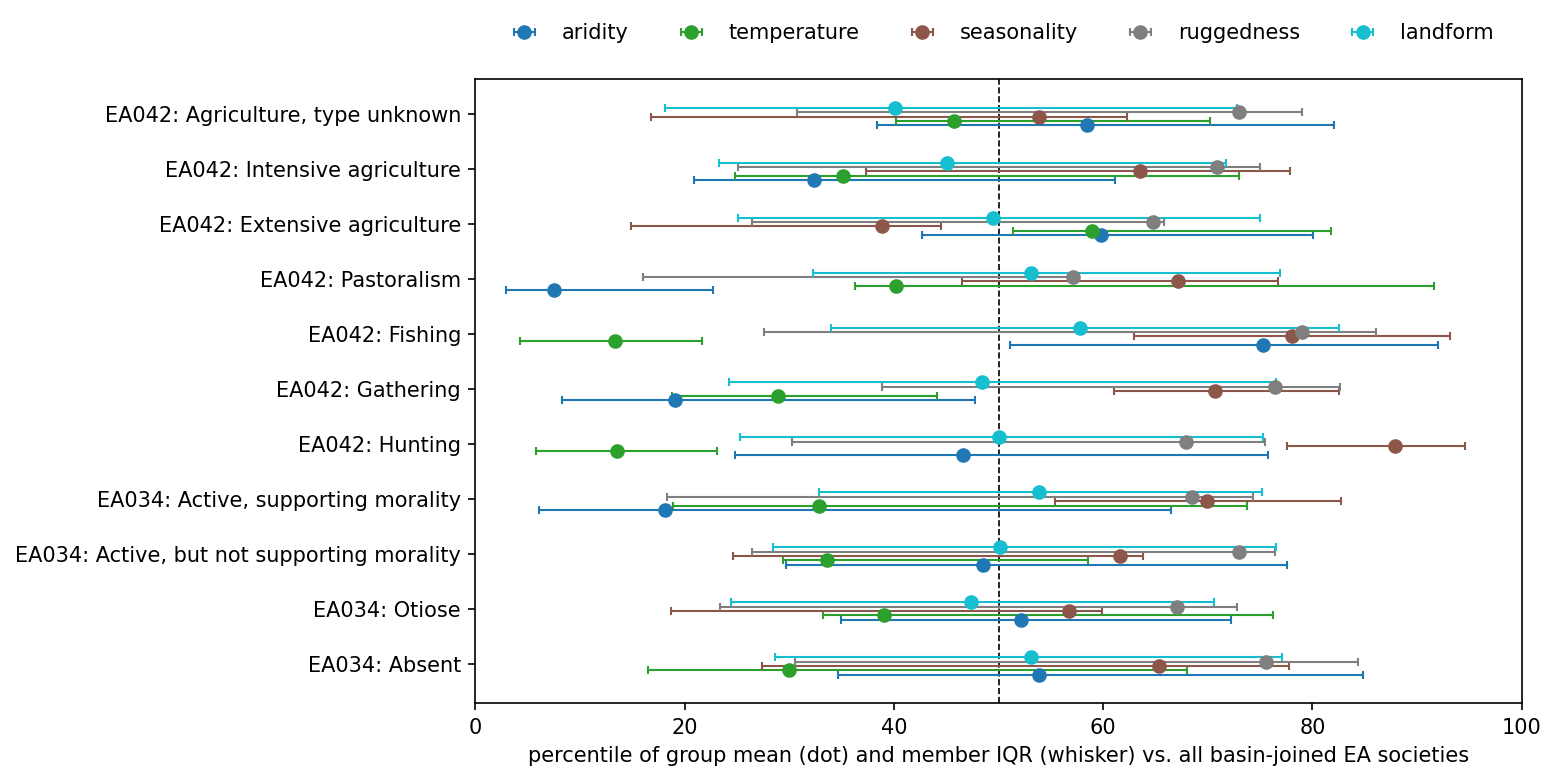

In [12]:
# Cell 8
print("drawing environmental profile comparison...")
fig, ax = plt.subplots(figsize=(9, 0.4 * len(profiles) + 1))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = plt.cm.tab10(np.linspace(0, 1, len(VAR_KEYS)))
for i, k in enumerate(VAR_KEYS):
    y = np.arange(len(profiles)) + (i - len(VAR_KEYS) / 2) * 0.08  # slight offset so whiskers don't overlap
    lo = (profiles[k] - profiles[f'{k}__p25']).clip(lower=0)
    hi = (profiles[f'{k}__p75'] - profiles[k]).clip(lower=0)
    ax.errorbar(profiles[k], y, xerr=[lo, hi], fmt='o', color=colors[i], label=k,
                markersize=6, capsize=2, elinewidth=1, zorder=3)

ax.axvline(50, color='black', linestyle='--', linewidth=0.8, zorder=1)
ax.set_yticks(range(len(profiles)))
ax.set_yticklabels(profiles.index, color='black')
ax.set_xlabel('percentile of group mean (dot) and member IQR (whisker) vs. all basin-joined EA societies',
              color='black')
ax.set_xlim(0, 100)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=5, frameon=False, labelcolor='black')

outpath = OUT / 'wo1_env_profile_comparison.png'
fig.savefig(outpath, facecolor='white', dpi=150, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

**Reading:** the whiskers add two things a single dot can't: width (is the group homogeneous or spread out?) and dot position within the whisker (is the group's distribution symmetric, or is the mean being pulled off from where the bulk of members actually sit?). For the pair that matters most here -- Pastoralism and Active-supporting-morality -- the dots sit reasonably centered within their own whiskers on all five variables. No hidden skew undermining the mean-based read from earlier: the aridity/seasonality/landform coincidence and the ruggedness mismatch both hold up once spread is visible, not just an artifact of comparing two single points. One row does stand out as genuinely skewed and worth flagging on its own terms: `EA042: Hunting`'s seasonality whisker stretches unusually wide (out past 90), with the dot sitting near the right edge rather than centered -- a right-skewed, spread-out distribution. Not central to the Pastoralism story, but a real feature of the chart.

## Conclusions

**Verdict: residual, not mediated -- yet.** The Pastoralism / Active-supporting-morality association is real and specific. It is not a general "arid societies have moralizing gods" pattern: Gathering's aridity percentile (19.1) is nearly identical to Active-supporting-morality's (18.1) -- markedly *higher* (less arid) than Pastoralism's (7.5), the most arid group in the table -- and Gathering shows almost no Active-moral association at all (3.6%, output 2). So aridity by itself clearly doesn't produce moralizing gods; Pastoralism's specific combination of profile *and* demonstrated association is what's doing the work, not shared aridity in isolation. The pattern also survives continental stratification, most convincingly in Africa (output 3) -- which rules out the simplest artifact (one region's baseline driving the whole global number), even though Asia and Europe individually carry less weight than a first read suggests. And it survives at the individual-member level too (output 4 with dispersion): neither group turns out to be a wide or skewed mix hiding behind a misleading mean.

What keeps this from being called "mediated" outright: **the single biggest available confound is also the most plausible one for this exact pattern.** Pastoralism-heavy societies in this dataset are concentrated in the Sahel and Central Asia -- precisely the historical Islamic-contact corridor. Nothing in this notebook's data distinguishes "arid rangeland pastoralism causally favors moralizing high gods" from "pastoralist regions and Abrahamic-contact regions happen to overlap heavily, and the religion variable is really tracking contact, not subsistence." Both produce the same table. That is not a hedge -- it's the specific, nameable alternative explanation for *this* finding, not a generic disclaimer, and this notebook has no religion-contact variable wired to adjudicate it (see below).

Fishing / Absent high gods does not survive scrutiny as a general subsistence-environment pattern -- output 3 traced it to a North American/Pacific-coastal regional effect, not a cross-continental one. Output 4 adds independent evidence from the environmental side: `EA034: Absent`'s profile (aridity 53.8, temperature 29.9) diverges substantially from `EA042: Fishing`'s (aridity 75.3, temperature 13.3) -- a bigger gap on both dimensions than Pastoralism/Active-moral's single worst mismatch (ruggedness, an 11-point gap). If Fishing were really mediating Absent the way Pastoralism mediates Active-moral, the two profiles should coincide the way that pair's does; they don't.

**What this notebook does not control for, regardless of outcome:**

- **Abrahamic and other world-religion contact.** No religion-contact coding is wired into this substrate -- this is the specific confound named above, not a generic gap. D-PLACE's own World Religions dataset (SCCS, 186 societies) is out of scope for this pass -- see `docs/edop/similarity_narrative_20260809.md` for how narrow that coverage actually is relative to EA's 1,291.
- **Social complexity.** Awaits Seshat data, Phase 4 (`docs/edop/early/project_summary_20260605.md`) -- not available here.
- **Basin-join bias** stated in section 0 above -- non-random with respect to environment; output 4 is restricted to the 1,133 of 1,291 EA societies that survive it (confirmed at the top of this notebook, Cell 2).
- **Contact-based diffusion within continental strata.** Family-restricted permutation (the standard control for shared ancestry) does not control for a trait spreading by *contact* across unrelated language families within a region -- this is the mechanism most likely responsible for the Pastoralism finding surviving continental control without actually being causal. See the register note filed alongside this notebook (`docs/design/deferred_items_register.md`, "DOCSv4 — worked-example notebook").